## Analysing the Raw data

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Raw Data

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\PycharmProjects\laptop-battery-health-predictor\data\battery_health_dataset.csv")
df.head(10)

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,1500,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,81.514041
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,7,9.628460,0,50956,1500,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552
5,7,7.584193,0,58928,1500,56.556801,37.835722,79.712851,32.096544,43334.547962,70.980071
6,8,5.555552,1,54721,1500,67.622296,73.197305,83.960476,34.940727,37844.844854,69.580059
7,7,11.537404,0,56157,1500,83.142065,60.329310,116.212847,34.605075,40967.426951,74.850306
8,1,6.952252,0,51696,161,54.529712,33.191792,76.280107,28.872215,50087.394430,96.916534
9,9,7.655985,0,72862,1500,55.023629,41.232222,95.948667,29.625280,55898.829903,75.864935


### 3. Shape & Missing values of the data

In [3]:
print(df.isnull().sum())
print(df.shape)

Battery Age             0
Daily Usage Hours       0
Gaming User             0
Design Capacity         0
Cycle Count             0
CPU Usage               0
GPU Usage               0
Power Consumption       0
Average Temperature     0
Full Charge Capacity    0
Battery Health          0
dtype: int64
(1200, 11)


### 4. Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Battery Age           1200 non-null   int64  
 1   Daily Usage Hours     1200 non-null   float64
 2   Gaming User           1200 non-null   int64  
 3   Design Capacity       1200 non-null   int64  
 4   Cycle Count           1200 non-null   int64  
 5   CPU Usage             1200 non-null   float64
 6   GPU Usage             1200 non-null   float64
 7   Power Consumption     1200 non-null   float64
 8   Average Temperature   1200 non-null   float64
 9   Full Charge Capacity  1200 non-null   float64
 10  Battery Health        1200 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 103.3 KB


### 5. Statistical analysis

In [5]:
df.describe()

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.571667,6.435078,0.102500,62049.919167,993.813333,50.047021,37.081954,68.510005,30.483731,51798.125944,82.944518
std,2.831939,3.149664,0.303431,10096.807179,527.254899,18.859965,17.485642,21.213489,2.624044,11598.140456,9.924455
min,0.000000,1.002497,0.000000,45002.000000,0.000000,9.151884,5.000000,20.133013,22.908857,28181.020459,59.840266
25%,2.000000,3.722104,0.000000,53583.250000,530.500000,34.223028,24.084790,52.238214,28.758142,42865.372454,75.315849
50%,5.000000,6.322145,0.000000,61888.000000,1188.000000,50.097711,34.979134,67.399336,30.398357,51698.379658,81.461246
75%,7.000000,9.162563,0.000000,70734.750000,1500.000000,64.294947,46.615097,82.529511,32.231464,60403.354634,91.414773
max,9.000000,11.986722,1.000000,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,79263.000000,100.000000


Observations
1. There are 1200 observations and 11 features
2. All features contain no Null values and all are numeric
3. "Gaming User" is a binary feature
4. Battery Health is the target feature, and it ranges between 59.8 - 100.0
5. "Cycle Count" may have an upperbound of 1500

### 6. Duplicate checking

In [7]:
df.duplicated().sum()

np.int64(0)

the dataset has no duplicates

### 7. Correlation Analysis

In [8]:
df.corr()["Battery Health"]

Battery Age            -0.900723
Daily Usage Hours      -0.084347
Gaming User             0.018509
Design Capacity         0.289450
Cycle Count            -0.921454
CPU Usage              -0.052363
GPU Usage              -0.033122
Power Consumption      -0.048988
Average Temperature    -0.041134
Full Charge Capacity    0.704030
Battery Health          1.000000
Name: Battery Health, dtype: float64

"Battery Age", "Cycle Count", "Full Charge Capacity" has strong correlation with Battery health others are weak. So these are the most important columns

### 8. Unique values

In [11]:
df.nunique()

Battery Age               10
Daily Usage Hours       1200
Gaming User                2
Design Capacity         1175
Cycle Count              562
CPU Usage               1194
GPU Usage               1199
Power Consumption       1200
Average Temperature     1200
Full Charge Capacity    1200
Battery Health          1160
dtype: int64

### 9. Value distribution

In [12]:
df["Cycle Count"].value_counts()

Cycle Count
1500    415
0        55
736       5
453       5
970       4
       ... 
1270      1
1255      1
974       1
12        1
1217      1
Name: count, Length: 562, dtype: int64

Total entries 1200, 415 rows have 1500 cycles, that is ~34% , could be a upper limit of the dataset

### 10. Heatmap

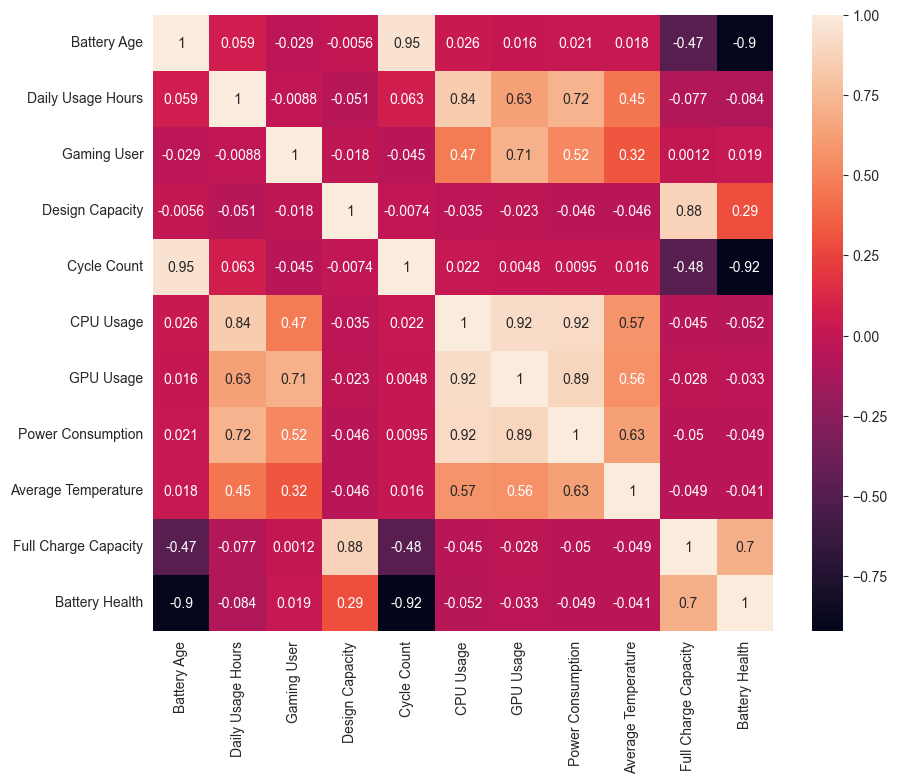

In [15]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

### 11. Target feature relations with others

11.1 Distribution

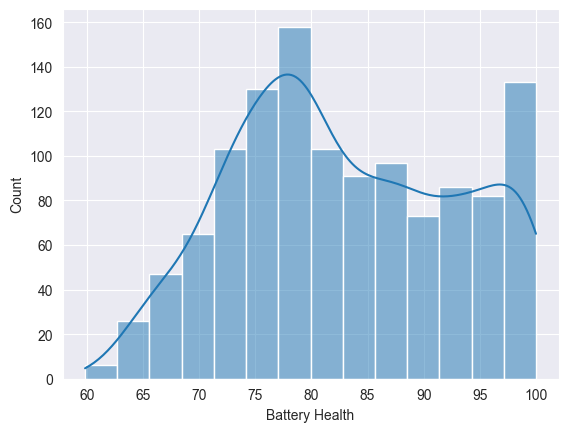

In [16]:
sns.histplot(df["Battery Health"], kde=True)
plt.show()

11.2 Relation with others

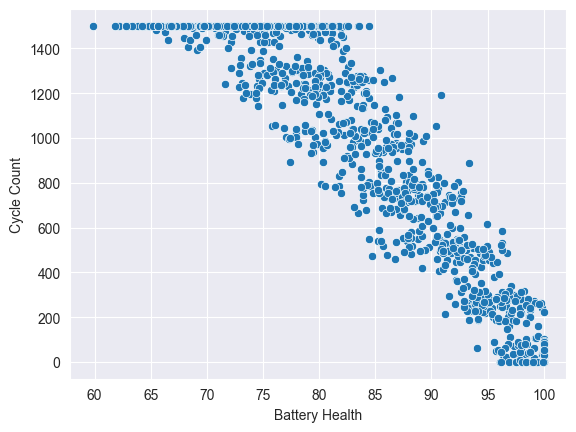

In [17]:
sns.scatterplot(
    data=df,
    x="Battery Health",
    y="Cycle Count",
)
plt.show()

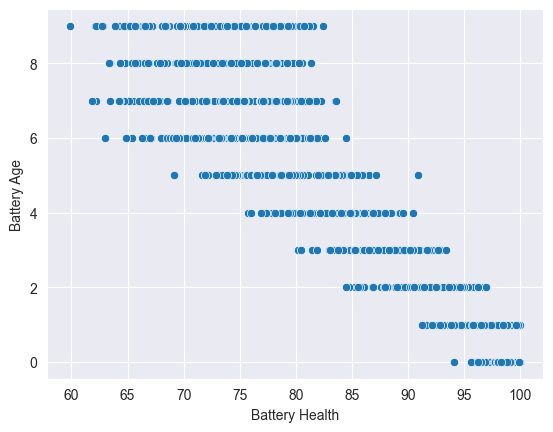

In [18]:
sns.scatterplot(
        data=df,
        x="Battery Health",
        y="Battery Age",
    )
plt.show()

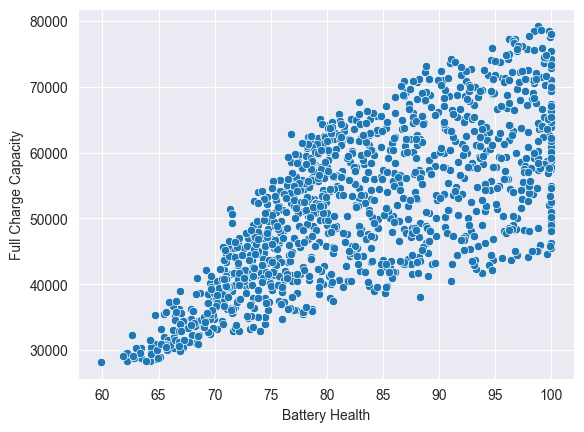

In [19]:
sns.scatterplot(
    data=df,
    x="Battery Health",
    y="Full Charge Capacity",
)
plt.show()

### 12. targate Leakage checking

In [22]:
l = pd.DataFrame({
    "Actual": df["Battery Health"],
    "Calculated": df["Full Charge Capacity"]/df["Design Capacity"]*100
})
print(l.head(20))

        Actual  Calculated
0    76.923383   77.675930
1    73.496153   73.044099
2    81.514041   79.763543
3    79.742100   82.443229
4    67.882552   68.210570
5    70.980071   73.538128
6    69.580059   69.159637
7    74.850306   72.951595
8    96.916534   96.888336
9    75.864935   76.718770
10  100.000000   99.868103
11   68.788598   68.169906
12   93.439149   92.714729
13   93.221087   95.043497
14   90.780060   90.414831
15   77.019914   76.743661
16   70.225780   68.803337
17   96.578087   96.691500
18  100.000000  100.000000
19   82.883920   82.760417


### Conclusion
1. Dataset is overall clean
2. There is an upperbound of 1500 in "Cycle Counts"
3. Battery Health can be derived from two internal features, Full Charge Capacity & Design Capacity
4. There are no Outlier found